# Week 4 Day 1 Lab


Generally useful functions:
```python
df.head()
df.tail()
df.info()
df.describe()
df.shape
df.columns
df.isnull().sum()
df.duplicated().sum()
df.corr(numeric_only=True)
df.value_counts()
```

Useful plotting functions:

```python
plt.hist()
plt.scatter()
plt.bar()
plt.boxplot()
df.plot()
```

where `df` is a `pandas.DataFrame` object and `plt` is the `matplotlib.pyplot` library


### Problem 1: Data Selection

Choose **one** of the following datasets on GitHub:
- Iris Dataset
- Titanic Dataset


In [ ]:
#Titanic Dataset

### Problem 2: Loading the Data
1. Load the dataset into a Pandas DataFrame.
2. Display the first five rows.
3. Display the last five rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/lukelewis/Downloads/Math300_Week3/titanic.csv')

print("First five rows:")
print(df.head())

print("Last five rows:")
print(df.tail())

First five rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

### Problem 3: Inspect Data
1. How many rows are in the dataset?
2. How many columns are in the dataset?
3. What are the column names?
4. What data type is each column?
5. Are there any missing values?
6. Are there any duplicate rows?

In [2]:
rows, columns = df.shape

print("1. Number of rows:", rows)
print("2. Number of columns:", columns)

print("\n3. Column names:")
print(list(df.columns))

print("\n4. Data types of each column:")
print(df.dtypes)

print("\n5. Missing values in each column:")
print(df.isnull().sum())

print("\nYes, the dataset contaisn missing values, especially in the age and deck.")

print("\n6. NUmber of duplicate rows:")
print(df.duplicated().sum())

print("\nYes, there are duplicate rows in the dataset.")


1. Number of rows: 891
2. Number of columns: 12

3. Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

4. Data types of each column:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

5. Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Yes, the dataset contaisn missing values, especially in the age and deck.

6. NUmber of duplicate rows:
0

Yes, there are duplicate rows in the dataset.


### Problem 4: Summary Statistics
For each numerical column, compute the following:
- Mean
- Median
- Mode
- Minimum
- Maximum
- Standard deviation


1. Which variable has the greatest variation?
2. Which variable has the smallest variation?


In [5]:
numerical_columns = df.select_dtypes(include="number")

summary_stats = pd.DataFrame({
    "Mean": numerical_columns.mean(),
    "Median": numerical_columns.median(),
    "Mode": [numerical_columns[column].mode().iloc[0] for column in numerical_columns.columns
    ],
    "Minimum": numerical_columns.min(),
    "Maximum": numerical_columns.max(),
    "Standard Deviation": numerical_columns.std()
})

display(summary_stats.round(3))

greatest_variation = summary_stats["Standard Deviation"].idxmax()
smallest_variation = summary_stats["Standard Deviation"].idxmin()

print(
    f"1. The varriable with the greatest variation is '{greatest_variation}' with a standard deviation of {summary_stats.loc[greatest_variation, 'Standard Deviation']:.3f}."
)

print(
    f"2. The variable with the smallest variation is '{smallest_variation}' with a standard deviation of {summary_stats.loc[smallest_variation, 'Standard Deviation']:.3f}."
)



,Mean,Median,Mode,Minimum,Maximum,Standard Deviation
PassengerId,446.000,446.000,1.00,1.00,891.000,257.354
Survived,0.384,0.000,0.00,0.00,1.000,0.487
Pclass,2.309,3.000,3.00,1.00,3.000,0.836
Age,29.699,28.000,24.00,0.42,80.000,14.526
SibSp,0.523,0.000,0.00,0.00,8.000,1.103
Parch,0.382,0.000,0.00,0.00,6.000,0.806
Fare,32.204,14.454,8.05,0.00,512.329,49.693


1. The varriable with the greatest variation is 'PassengerId' with a standard deviation of 257.354.
2. The variable with the smallest variation is 'Survived' with a standard deviation of 0.487.


### Problem 5: Visualization
1. Choose a numerical column from your dataset and:
    - Plot the corresponding histogram. 
        - What does the distribution look like?
        - Is it symmetric or skewed?
    - Plot the corresponding box plot.
        - Are there any outliers?
        - Explain what you observe.
2. Choose one categorical column from your dataset and:
    - Plot the corresponding bar chart.
        - Which category occurs most frequently?
        - Which occurs least frequently?


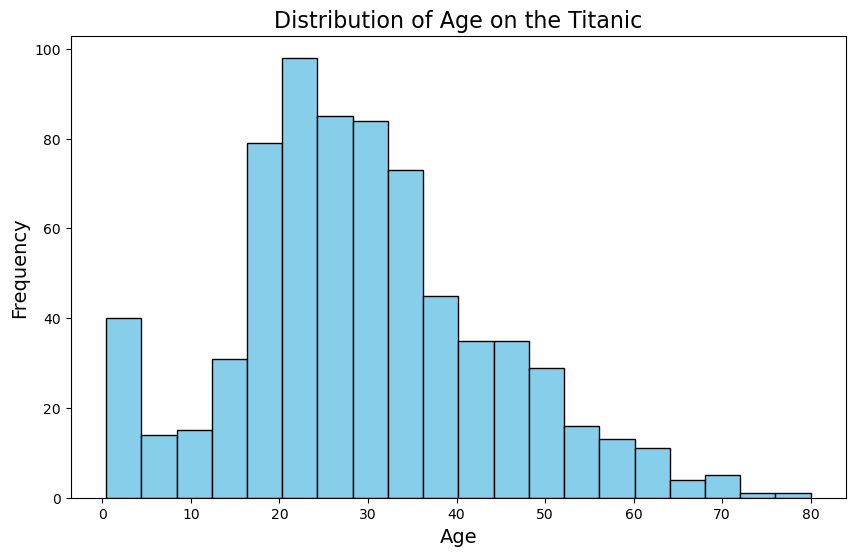

The age distribution is unimodal and slightly right-skewed.


In [ ]:
age_data = df["Age"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    age_data, bins=20, color="skyblue", edgecolor="black"
)

plt.title("Distribution of Age on the Titanic", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

print(
"The age distribution is unimodal and slightly right-skewed."
)


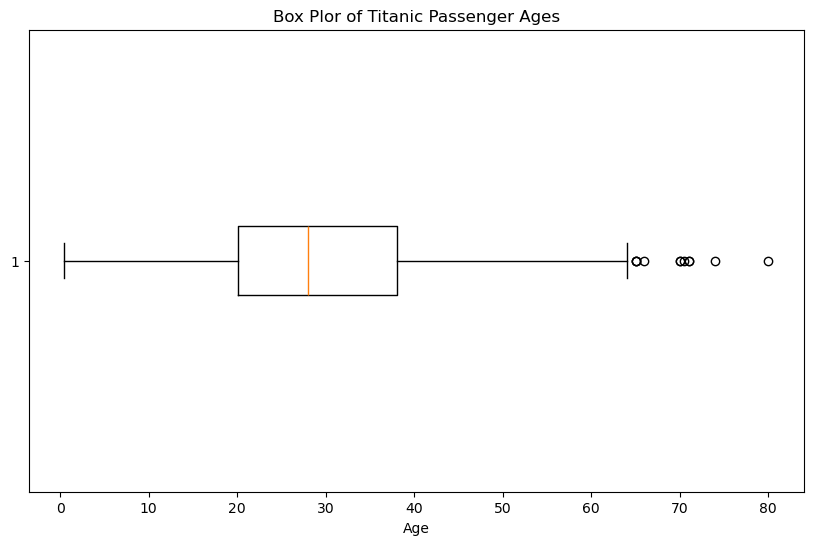

The box plot contains 11 outlier values.The are older passengers who are far above the typical age range.


In [8]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    age_data,
    vert=False
)

plt.title("Box Plor of Titanic Passenger Ages")
plt.xlabel("Age")

plt.show()

q1 = age_data.quantile(0.25)
q3 = age_data.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = age_data[
    (age_data < lower_bound) |
    (age_data > upper_bound)
]

print(
    f"The box plot contains {len(outliers)} outlier values."
    f"The are older passengers who are far above the typical age range."
)



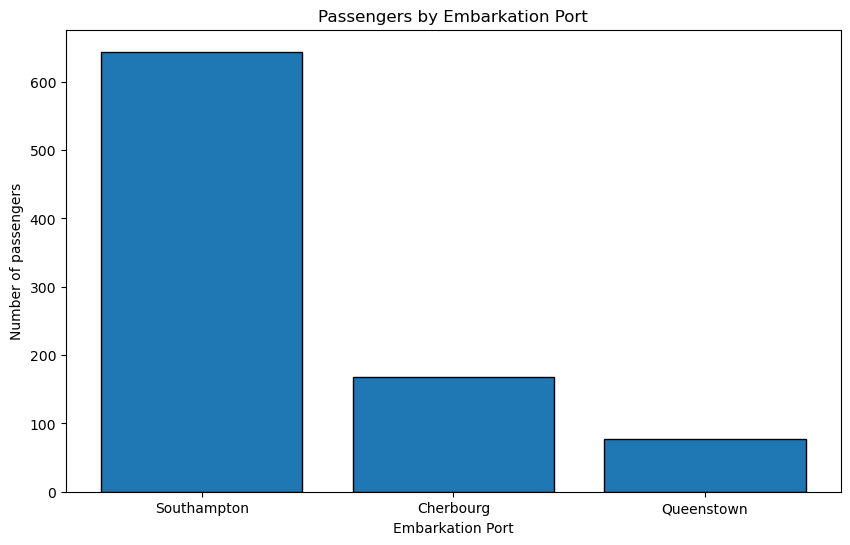

The most frequent category is Swith 644 passengers
The least frequent category is Qwith 77 passengers


In [12]:
embarked_counts = df["Embarked"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    embarked_counts.index,
    embarked_counts.values,
    edgecolor="black"
)

plt.title("Passengers by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Number of passengers")

plt.xticks(
    ticks=range(len(embarked_counts.index)),
    labels=[
        "Southampton" if x == "S"
        else "Cherbourg" if x == "C"
        else "Queenstown"
        for x in embarked_counts.index
    ]
)

plt.show()

print(
    f"The most frequent category is {embarked_counts.idxmax()}"
    f"with {embarked_counts.max()} passengers"
)

print(
    f"The least frequent category is {embarked_counts.idxmin()}"
    f"with {embarked_counts.min()} passengers" 
)
